In [1]:
import sys 
import os

In [2]:
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.insert(0, project_root)

In [3]:
import pandas as pd
import yaml
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [4]:
import statsmodels.api as sm

In [5]:
yaml_path = rf"..\config\config.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

In [6]:
yaml_path = rf"..\config\model.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config_model = yaml.safe_load(f)

# Params

# Read Train / val dataset

In [7]:
pipeline_name="Pipeline1"

In [8]:
X_train = pd.read_parquet(fr'..\data\feature_eng\X_train_feat_eng_{pipeline_name}.parquet')
y_train = pd.read_parquet(fr'..\data\feature_eng\y_train_feat_eng_{pipeline_name}.parquet')  

X_val = pd.read_parquet(fr'..\data\feature_eng\X_val_feat_eng_{pipeline_name}.parquet')
y_val = pd.read_parquet(fr'..\data\feature_eng\y_val_feat_eng_{pipeline_name}.parquet')

# Drop columns

In [10]:
# X_train.drop(
#     columns=config_model['single_model']['cols_2_drop'], 
#     inplace=True)

# X_val.drop(
#     columns=config_model['single_model']['cols_2_drop'], 
#     inplace=True)


In [11]:
X_train

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,categorical_pipe__Neighborhood_NAmes,categorical_pipe__ExterQual_TA,categorical_pipe__ExterQual_Gd,categorical_pipe__BsmtQual_TA,categorical_pipe__BsmtQual_Gd,categorical_pipe__SaleType_WD,num_con_1_robust__TotalBsmtSF
254,17.195067,8.247752,7,0,8,0,7,5,1,1,1,0,1,0,1,0.616177
1066,16.971792,8.482770,0,8,0,5,8,6,2,0,0,1,0,1,1,-0.445131
638,17.337405,7.596716,0,0,8,0,0,5,1,0,1,0,0,0,1,-0.451314
799,16.701672,8.639066,7,8,0,0,7,5,1,0,1,0,0,1,1,-0.585265
380,15.573121,8.580072,6,8,0,0,7,5,2,0,1,0,1,0,1,0.022669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,17.532284,8.247752,3,0,0,4,8,6,2,0,0,1,0,1,1,0.616177
1130,16.958276,8.790222,7,8,8,6,8,4,2,0,1,0,1,0,1,0.220505
1294,17.106263,7.702349,5,0,0,0,8,5,1,0,1,0,1,0,1,-0.311180
860,16.891196,8.355170,0,8,0,8,7,7,1,0,0,1,1,0,1,-0.212262


# Features

## LotArea

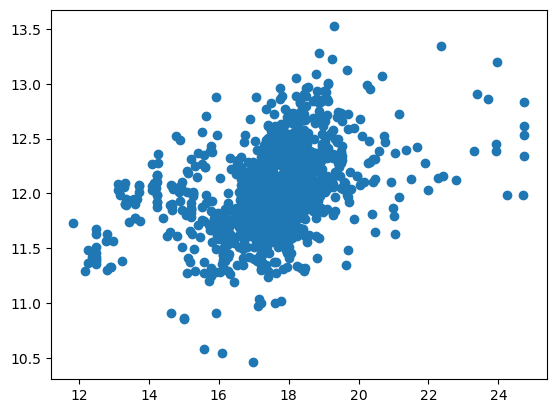

In [12]:
plt.scatter(
    x=X_train['num_con_1_pipe__LotArea'],
    y=y_train
                );

In [13]:
X = X_train['num_con_1_pipe__LotArea'].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     246.0
Date:                qua, 20 mai 2026   Prob (F-statistic):           1.89e-50
Time:                        18:53:07   Log-Likelihood:                -447.04
No. Observations:                1168   AIC:                             898.1
Df Residuals:                    1166   BIC:                             908.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

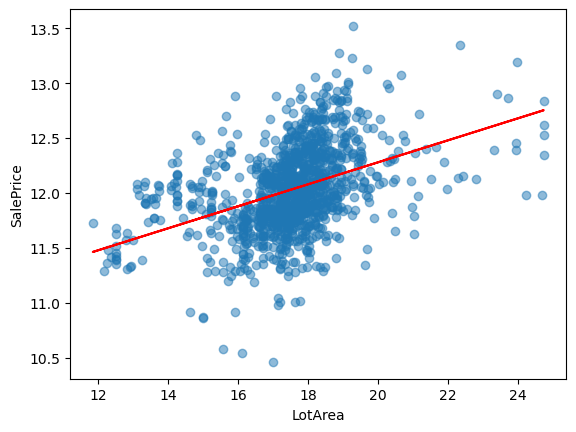

In [14]:
plt.scatter(
    x=X_train['num_con_1_pipe__LotArea'],
    y=y_train,
    alpha=0.5
)

plt.plot(
    X_train['num_con_1_pipe__LotArea'],
    results.fittedvalues,
    color='red'
)

plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.show()

## GrLivArea

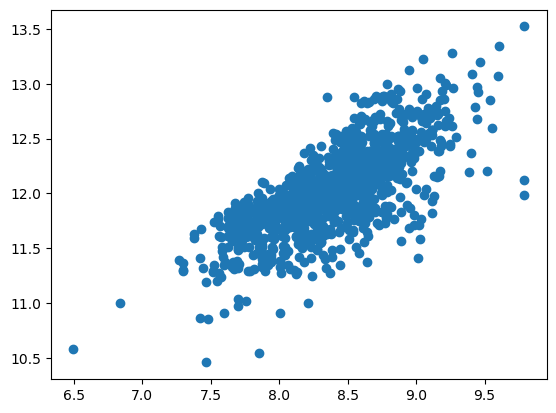

In [15]:
plt.scatter(
    x=X_train['num_con_1_pipe__GrLivArea'],
    y=y_train
                );

In [16]:
X = X_train['num_con_1_pipe__GrLivArea'].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     1301.
Date:                qua, 20 mai 2026   Prob (F-statistic):          6.41e-192
Time:                        18:53:37   Log-Likelihood:                -121.28
No. Observations:                1168   AIC:                             246.6
Df Residuals:                    1166   BIC:                             256.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

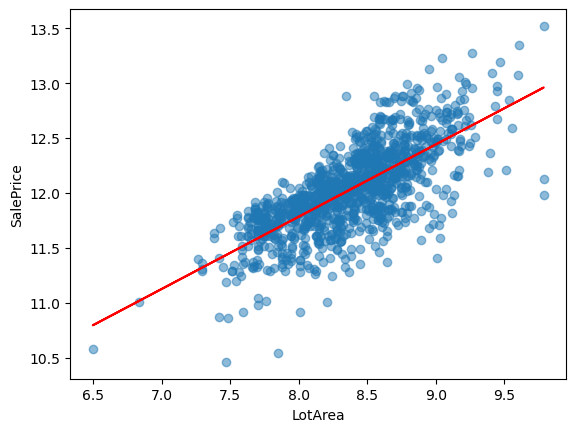

In [17]:
plt.scatter(
    x=X_train['num_con_1_pipe__GrLivArea'],
    y=y_train,
    alpha=0.5
)

plt.plot(
    X_train['num_con_1_pipe__GrLivArea'],
    results.fittedvalues,
    color='red'
)

plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.show()

## TotalBsmtSF

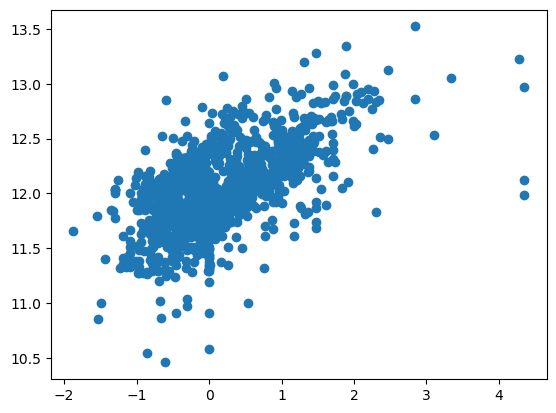

In [18]:
plt.scatter(
    x=X_train['num_con_1_robust__TotalBsmtSF'],
    y=y_train
                );

In [19]:
X = X_train['num_con_1_robust__TotalBsmtSF'].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     655.9
Date:                qua, 20 mai 2026   Prob (F-statistic):          3.89e-115
Time:                        18:55:17   Log-Likelihood:                -298.20
No. Observations:                1168   AIC:                             600.4
Df Residuals:                    1166   BIC:                             610.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

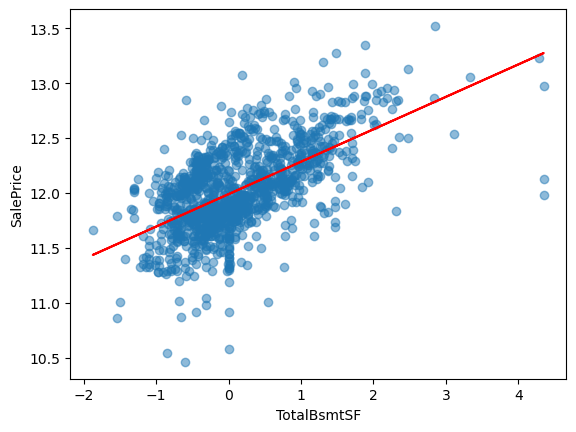

In [20]:
plt.scatter(
    x=X_train['num_con_1_robust__TotalBsmtSF'],
    y=y_train,
    alpha=0.5
)

plt.plot(
    X_train['num_con_1_robust__TotalBsmtSF'],
    results.fittedvalues,
    color='red'
)

plt.xlabel('TotalBsmtSF')
plt.ylabel('SalePrice')
plt.show()

 ## TotalBsmtSF e  GrLivArea

In [21]:
X = X_train[['num_con_1_robust__TotalBsmtSF', 'num_con_1_pipe__GrLivArea']].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.632
Method:                 Least Squares   F-statistic:                     1002.
Date:                qua, 20 mai 2026   Prob (F-statistic):          6.91e-254
Time:                        18:55:28   Log-Likelihood:                 25.590
No. Observations:                1168   AIC:                            -45.18
Df Residuals:                    1165   BIC:                            -29.99
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

 ## TotalBsmtSF ,  GrLivArea e LotArea

In [22]:
X_train[['num_con_1_robust__TotalBsmtSF', 'num_con_1_pipe__GrLivArea', 'num_con_1_pipe__LotArea']].corr()

,num_con_1_robust__TotalBsmtSF,num_con_1_pipe__GrLivArea,num_con_1_pipe__LotArea
num_con_1_robust__TotalBsmtSF,1.000000,0.421375,0.379409
num_con_1_pipe__GrLivArea,0.421375,1.000000,0.407354
num_con_1_pipe__LotArea,0.379409,0.407354,1.000000


In [23]:
X = X_train[['num_con_1_robust__TotalBsmtSF', 'num_con_1_pipe__GrLivArea', 'num_con_1_pipe__LotArea']].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     675.8
Date:                qua, 20 mai 2026   Prob (F-statistic):          2.60e-254
Time:                        18:55:32   Log-Likelihood:                 30.161
No. Observations:                1168   AIC:                            -52.32
Df Residuals:                    1164   BIC:                            -32.07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

## All Features

In [ ]:
X_train.columns

Index(['num_con_1_pipe__LotArea', 'num_con_1_pipe__GrLivArea',
       'num_con_2_pipe__BsmtFinSF1', 'num_con_2_pipe__2ndFlrSF',
       'num_con_2_pipe__GarageArea', 'num_dis_pipe__OverallQual',
       'num_dis_pipe__FullBath', 'num_dis_pipe__BedroomAbvGr',
       'num_dis_pipe__BsmtFullBath', 'categorical_pipe__Neighborhood_NAmes',
       'categorical_pipe__ExterQual_TA', 'categorical_pipe__BsmtQual_Gd',
       'categorical_pipe__BsmtCond_TA', 'categorical_pipe__SaleType_WD',
       'num_con_1_robust__TotalBsmtSF'],
      dtype='object')

In [ ]:
X = X_train.copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     292.0
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        08:30:31   Log-Likelihood:                -13886.
No. Observations:                1168   AIC:                         2.780e+04
Df Residuals:                    1152   BIC:                         2.789e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [ ]:
df_tmp = pd.concat([X_train, y_train], axis=1)

In [ ]:
df_tmp.columns

Index(['num_con_1_pipe__LotArea', 'num_con_1_pipe__GrLivArea',
       'num_con_2_pipe__BsmtFinSF1', 'num_con_2_pipe__2ndFlrSF',
       'num_con_2_pipe__GarageArea', 'num_dis_pipe__OverallQual',
       'num_dis_pipe__FullBath', 'num_dis_pipe__BedroomAbvGr',
       'num_dis_pipe__BsmtFullBath', 'categorical_pipe__Neighborhood_NAmes',
       'categorical_pipe__ExterQual_TA', 'categorical_pipe__BsmtQual_Gd',
       'categorical_pipe__BsmtCond_TA', 'categorical_pipe__SaleType_WD',
       'num_con_1_robust__TotalBsmtSF', 'SalePrice'],
      dtype='object')

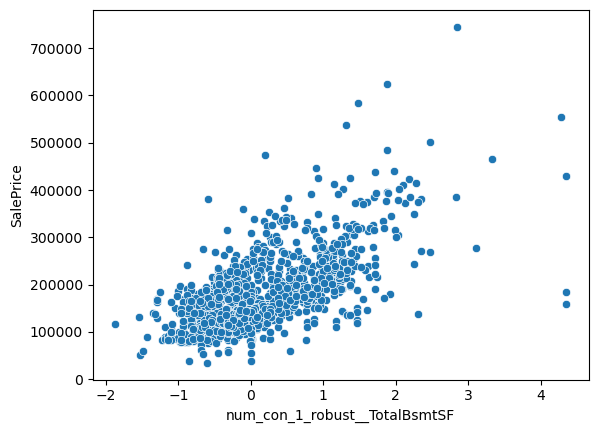

In [ ]:
sns.scatterplot(
    data=df_tmp,
    x='num_con_1_robust__TotalBsmtSF',
    y='SalePrice',
    # hue='categorical_pipe__SaleCondition_Normal',

)

plt.show()

In [ ]:
mean_squared_error(y_val, y_pred)

In [24]:
from sklearn.kernel_ridge import KernelRidge

In [49]:
model = KernelRidge(
    kernel='rbf',
    gamma=0.05,
    alpha=0.3
)

In [50]:
model.fit(X_train, y_train)

KernelRidge(alpha=0.3, gamma=0.05, kernel='rbf')

In [51]:
y_pred = model.predict(X_val)

In [52]:
mean_squared_error(y_val, y_pred)

1.3951190748978366

In [53]:
r2_score(y_val, y_pred)

-6.476082118455913

In [54]:
mean_absolute_percentage_error(y_val, y_pred)

0.054647681888302574